In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import stable_retro
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym

#### Mario Environment and Rewards

In [44]:
def compute_reward(prev_info, curr_info, done):
    reward = 0.0

    # --- Progress ---
    curr_pos = curr_info.get('screen', 0) * 256 + curr_info['x']
    prev_pos = prev_info.get('screen', 0) * 256 + prev_info['x']
    delta_x = curr_pos - prev_pos
    if 0 < delta_x < 200:
        reward += delta_x * 0.01

    # --- Milestones ---
    if curr_info.get('midpoint_flag', 0) > prev_info.get('midpoint_flag', 0):
        reward += 5.0
    if curr_info.get('FINISH', 0) > prev_info.get('FINISH', 0):
        reward += 10.0

    # --- Powerups ---
    if curr_info.get('powerup_status', 0) > prev_info.get('powerup_status', 0):
        reward += 1.0

    # --- Penalties ---
    if curr_info['lives'] < prev_info['lives']:
        reward -= 5.0

    return reward

In [45]:
class SMWEnv(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        # Override the observation space to match your tuple state
        self.observation_space = gym.spaces.Box(
            low=np.array([0, 0, 0, 0, 0], dtype=np.float32),
            high=np.array([255, 9999, 3, 1, 1], dtype=np.float32),
            dtype=np.float32
        )
        self.prev_info = {}

    def reset(self, **kwargs):
        _, info = self.env.reset(**kwargs)
        self.prev_info = {'x': 0, 'screen': 0, 'powerup_status': 0, 'riding_yoshi': 0, 'midpoint_flag': 0, 'lives': 4, 'score': 0, 'coins': 0}
        obs = self.get_obs(info)
        return obs, info

    def step(self, action):
        _, _, terminated, truncated, info = self.env.step(action)
        obs = self.get_obs(info)
        reward = compute_reward(self.prev_info, info, terminated or truncated)
        self.prev_info = info
        return obs, reward, terminated, truncated, info

    def get_obs(self, info):
        return np.array([
            info.get('screen', 0),
            info.get('x', 0),
            info.get('powerup_status', 0),
            info.get('riding_yoshi', 0),
            info.get('midpoint_flag', 0),
        ], dtype=np.float32)

#### Actor and Critic

In [46]:
class Actor(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.fc1 = nn.Linear(obs_dim, 64)   # 5 inputs → 64 neurons
        self.fc2 = nn.Linear(64, 64)        # 64 → 64
        self.fc3 = nn.Linear(64, action_dim) # 64 → one output per action

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        probs = F.softmax(self.fc3(x), dim=-1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob

class Critic(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.obs_dim = obs_dim
        self.fc1 = nn.Linear(obs_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        V = self.fc3(x)
        return V

#### PPO Algorithm

In [47]:
base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode=None)
env = SMWEnv(base_env)

total_rewards = []
steps_per_ep  = []
max_x_per_ep  = []
actor_losses  = []
critic_losses = []

RuntimeError: Cannot create multiple emulator instances per process, make sure to call env.close() on each environment before creating a new one

In [ ]:
try:
    base_env.close()
except:
    pass

In [ ]:
class SMW_PPO:
    def __init__(self, env, obs_dim, action_dim, theta, n_workers, epsilon = 0.2, alpha = 0.95, gamma=0.99, num_steps=2048):
        self.env = env
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.num_steps = num_steps
        self.n_workers = n_workers
        self.num_eps = 50

        #create array for collecting trajectories
        self.states    = []
        self.actions   = []
        self.rewards   = []
        self.log_probs = []
        self.values    = []
        self.dones     = []
        self.theta = theta

        self.state, _ = self.env.reset()

        #call in my actor and critic class and optimize them
        self.actor = Actor(obs_dim=5, action_dim=self.env.action_space.n)
        self.critic = Critic(obs_dim=5)
        self.actor_optimizer  = optim.Adam(self.actor.parameters(),  lr=3e-4)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-3)

        self.policy = []
        
    def collect_trajectories(self):
        #iterate through my steps typically PPO is 2048
        for _ in range(self.num_steps):
            
            #set up my actor and critic
            action, log_prob = self.actor(torch.tensor(self.state, dtype=torch.float32))
            action_idx = action.item()
            action_onehot = np.zeros(self.env.action_space.n, dtype=np.uint8)
            action_onehot[action_idx] = 1
            next_state, reward, terminated, truncated, info = self.env.step(action_onehot)
            done = terminated or truncated
            value = self.critic(torch.tensor(self.state, dtype=torch.float32))


            #grab all my trajectories and append them
            self.states.append(self.state)
            self.actions.append(action_idx)
            self.rewards.append(reward)
            self.log_probs.append(log_prob)
            self.values.append(value)
            self.dones.append(done)

            # reset if episode ended
            if done:
                self.state, _ = self.env.reset()
            else:
                self.state = next_state

        #return my set of trajectories
        return self.states, self.actions, self.rewards, self.log_probs, self.values, self.dones

    def r_to_go(self):
        Rt = []
        discounted_sum = 0
        
        #grab all rewards and dones and add them into my discounted sum
        for reward, done in zip(reversed(self.rewards), reversed(self.dones)):
            if done:
                discounted_sum = 0

            discounted_sum = reward + self.gamma * discounted_sum
            Rt.insert(0, discounted_sum)

        return Rt

    # def advantage_est(self):
    #     gae = torch.GAE(self.n_workers, self.num_steps, self.gamma, self.alpha)
    #     return gae

    def advantage_est(self):
        #take a generic advantage estimation
        Rt = torch.tensor(self.r_to_go(), dtype=torch.float32)
        V  = torch.stack(self.values).squeeze()
        advantages = Rt - V.detach()
        return advantages
    
    def update(self):
        states_t = torch.tensor(np.array(self.states),    dtype=torch.float32)
        
        # get new log_probs and values from current networks
        _, new_log_probs = self.actor(states_t)
        new_values = self.critic(states_t).squeeze()

        # compute the probability ratio π_new / π_old
        old_logs = torch.stack(self.log_probs).detach()
        ratio = torch.exp(new_log_probs - old_logs)

        # compute advantages
        advantages = self.advantage_est().detach()

        #two candidates for the loss
        unclipped = ratio * advantages
        clipped = torch.clamp(ratio, 1-self.epsilon, 1+self.epsilon) * advantages

        # take the minimum (pessimistic bound)
        actor_loss = -torch.mean(torch.min(unclipped, clipped))
        
        # critic just minimizes prediction error
        critic_loss = nn.MSELoss()(new_values, torch.tensor(self.r_to_go(), dtype=torch.float32))

        # backprop actor
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # backprop critic
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        return actor_loss.item(), critic_loss.item()
        
    def clear_buffer(self):
        self.states    = []
        self.actions   = []
        self.rewards   = []
        self.log_probs = []
        self.values    = []
        self.dones     = []

    def rollout(self):
        for ep in range(self.num_eps):
            self.collect_trajectories()
            self.update()

            total_rewards.append(sum(self.rewards))
            steps_per_ep.append(len(self.rewards))
            max_x_per_ep.append(max(s[0] * 256 + s[1] for s in self.states))
            actor_loss, critic_loss = self.update()
            actor_losses.append(actor_loss)
            critic_losses.append(critic_loss)

            self.clear_buffer()
            print(f"Episode {ep+1}/{self.num_eps} | Reward: {total_rewards[-1]:.2f} | Max X: {max_x_per_ep[-1]}")

In [ ]:
agent = SMW_PPO(env=env, obs_dim=5, action_dim=env.action_space.n, theta=None, n_workers=1)
agent.rollout()

Episode 1/50 | Reward: 1.29 | Max X: 49.0
Episode 2/50 | Reward: 1.67 | Max X: 43.0
Episode 3/50 | Reward: 1.08 | Max X: 47.0
Episode 4/50 | Reward: 1.37 | Max X: 52.0
Episode 5/50 | Reward: 1.72 | Max X: 74.0
Episode 6/50 | Reward: 1.43 | Max X: 81.0
Episode 7/50 | Reward: 1.66 | Max X: 93.0
Episode 8/50 | Reward: -4.12 | Max X: 38.0
Episode 9/50 | Reward: 1.60 | Max X: 69.0
Episode 10/50 | Reward: 1.13 | Max X: 79.0
Episode 11/50 | Reward: 1.62 | Max X: 46.0
Episode 12/50 | Reward: 1.36 | Max X: 61.0
Episode 13/50 | Reward: 1.63 | Max X: 105.0
Episode 14/50 | Reward: 0.89 | Max X: 100.0
Episode 15/50 | Reward: 1.50 | Max X: 45.0
Episode 16/50 | Reward: 1.42 | Max X: 51.0
Episode 17/50 | Reward: -4.77 | Max X: 255.0
Episode 18/50 | Reward: 0.45 | Max X: 255.0
Episode 19/50 | Reward: 0.67 | Max X: 255.0
Episode 20/50 | Reward: 0.93 | Max X: 255.0
Episode 21/50 | Reward: 1.62 | Max X: 255.0
Episode 22/50 | Reward: 2.44 | Max X: 250.0
Episode 23/50 | Reward: 0.59 | Max X: 147.0
Episode 2

ValueError: x and y must have same first dimension, but have shapes (100,) and (50,)

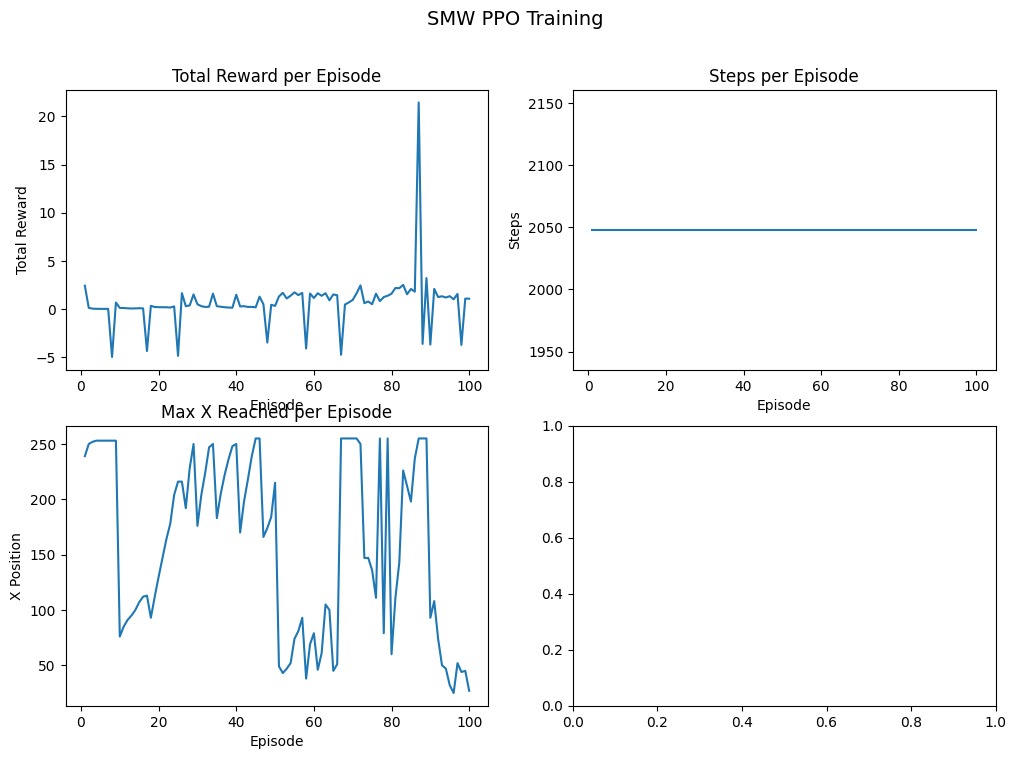

In [ ]:
num_eps = len(total_rewards)
eps = range(1, num_eps + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('SMW PPO Training', fontsize=14)

axes[0, 0].plot(eps, total_rewards)
axes[0, 0].set_title('Total Reward per Episode')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')

axes[0, 1].plot(eps, steps_per_ep)
axes[0, 1].set_title('Steps per Episode')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Steps')

axes[1, 0].plot(eps, max_x_per_ep)
axes[1, 0].set_title('Max X Reached per Episode')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('X Position')

axes[1, 1].plot(eps, actor_losses)
axes[1, 1].set_title('Actor Loss per Episode')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Loss')

plt.tight_layout()
plt.savefig('ppo_results.png')
plt.show()

In [ ]:
# test a bunch of addresses around where x should be
import stable_retro

env = stable_retro.make(game='SuperMarioWorld-Snes-v0', render_mode='human')
env.reset()

for _ in range(100):
    action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]  # hold right
    env.step(action)

ram = env.get_ram()
# print addresses in the range we care about
for addr in [0x00D1, 0x00D3, 0x0086, 0x00D4, 0x00B6, 0x00B8]:
    print(f"0x{addr:04X}: {ram[addr]}")
    print(0x7E0000 + 0x00D1)  # x
    print(0x7E0000 + 0x00D4)  # screen  

env.close()

0x00D1: 129
8257745
8257748
0x00D3: 96
8257745
8257748
0x0086: 0
8257745
8257748
0x00D4: 1
8257745
8257748
0x00B6: 0
8257745
8257748
0x00B8: 0
8257745
8257748
